In [1]:

import os, random, numpy as np, pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from sklearn.metrics import f1_score, classification_report
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Using device:', DEVICE)

Using device: cuda


**LOAD DATA**

In [2]:
DATA_DIR = Path('/kaggle/input/competitions/shift-guard-10-robust-image-classification-challenge')

TRAIN_IMG_DIR = DATA_DIR / 'train_images'
TEST_IMG_DIR  = DATA_DIR / 'test_images'
TRAIN_LABELS  = DATA_DIR / 'train_labels.csv'
SAMPLE_SUB    = DATA_DIR / 'sample_submission.csv'
CLASSES_FILE  = DATA_DIR / 'classes.txt'

with open(CLASSES_FILE) as f:
    class_names = [line.strip() for line in f if line.strip()]
NUM_CLASSES = len(class_names)
cls2idx = {c: i for i, c in enumerate(class_names)}
print('Classes:', class_names)

df = pd.read_csv(TRAIN_LABELS)
ID_COL    = df.columns[0]
LABEL_COL = df.columns[1]

if df[LABEL_COL].dtype == object:
    df['label_idx'] = df[LABEL_COL].map(cls2idx)
else:
    df['label_idx'] = df[LABEL_COL]

print(df.head())
print('\nSamples per class:')
print(df['label_idx'].value_counts().sort_index())

Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
   id       label  label_idx
0   1         cat          3
1   2         dog          5
2   3        deer          4
3   4  automobile          1
4   5        bird          2

Samples per class:
label_idx
0    5000
1    5000
2    5000
3    5000
4    4000
5    4000
6     500
7     500
8     300
9     100
Name: count, dtype: int64


**TRAIN/VAL SPLIT**

In [3]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df, test_size=0.1,
    stratify=df['label_idx'],
    random_state=SEED
)
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)
print(f'Train: {len(train_df)}  Val: {len(val_df)}')

Train: 26460  Val: 2940


**DATASET CLASSES**

In [4]:
class ImageDataset(Dataset):
    def __init__(self, df, img_dir, transform, id_col, label_col=None):
        self.df        = df
        self.img_dir   = Path(img_dir)
        self.transform = transform
        self.id_col    = id_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_name = str(row[self.id_col]).zfill(6)

        img_path = None
        for ext in ['', '.png', '.jpg', '.jpeg']:
            p = self.img_dir / f"{img_name}{ext}"
            if p.exists():
                img_path = p
                break
        if img_path is None:
            raise FileNotFoundError(f"Image not found: {img_name}")

        img = Image.open(img_path).convert('RGB')
        img = self.transform(img)

        if self.label_col:
            return img, int(row[self.label_col])
        return img, img_name
           
       

**TRANSFORMS AND DATALOADERS**

In [5]:
MEAN = [0.4914, 0.4822, 0.4465]
STD  = [0.2470, 0.2435, 0.2616]

train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])

val_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

tta_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

BATCH_SIZE = 256

train_ds = ImageDataset(train_df, TRAIN_IMG_DIR, train_transform, ID_COL, 'label_idx')
val_ds   = ImageDataset(val_df,   TRAIN_IMG_DIR, val_transform,   ID_COL, 'label_idx')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Train batches: {len(train_loader)}')

Train batches: 104


**CNN MODEL**

In [6]:
class ResidualBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1    = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1      = nn.BatchNorm2d(out_ch)
        self.conv2    = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2      = nn.BatchNorm2d(out_ch)
        self.relu     = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class StrongCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.entry = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.layer1 = nn.Sequential(ResidualBlock(64, 64),  ResidualBlock(64, 64))
        self.layer2 = nn.Sequential(ResidualBlock(64, 128, stride=2), ResidualBlock(128, 128))
        self.layer3 = nn.Sequential(ResidualBlock(128, 256, stride=2), ResidualBlock(256, 256))
        self.pool   = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.entry(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.pool(x)
        return self.classifier(x)


model = StrongCNN(num_classes=NUM_CLASSES).to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')

Parameters: 2,777,674


**MIXUP**

In [7]:
def mixup_batch(images, labels, num_classes, alpha=0.4):
    """Blends two random images and their labels together."""
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(images.size(0), device=images.device)

    mixed_images = lam * images + (1 - lam) * images[idx]

    # Convert labels to one-hot for soft blending
    y_a = torch.zeros(images.size(0), num_classes, device=images.device)
    y_b = torch.zeros(images.size(0), num_classes, device=images.device)
    y_a.scatter_(1, labels.view(-1, 1), 1)
    y_b.scatter_(1, labels[idx].view(-1, 1), 1)

    mixed_labels = lam * y_a + (1 - lam) * y_b
    return mixed_images, mixed_labels


def mixup_loss(preds, mixed_labels):
    """Cross entropy that works with soft blended labels."""
    log_probs = torch.log_softmax(preds, dim=1)
    return -(mixed_labels * log_probs).sum(dim=1).mean()

**TRAINING SETUP**

In [8]:
EPOCHS = 200

criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

optimizer = optim.SGD(
    model.parameters(),
    lr=0.1,
    momentum=0.9,
    weight_decay=5e-4,
    nesterov=True
)

# Warmup for 5 epochs then cosine decay
def lr_lambda(epoch):
    if epoch < 5:
        return (epoch + 1) / 5      # warmup
    progress = (epoch - 5) / (EPOCHS - 5)
    return 0.5 * (1 + np.cos(np.pi * progress))  # cosine decay

scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

**TRAIN AND VALIDATE FUNCTIONS**

In [9]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images)
        loss  = criterion(preds, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        correct    += (preds.argmax(1) == labels).sum().item()
        total      += images.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        preds = model(images)
        total_loss += criterion(preds, labels).item() * images.size(0)
        all_preds.extend(preds.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(all_labels), f1_score(all_labels, all_preds, average='macro')

**RUN TRAINING**

In [10]:
best_f1   = 0.0
history   = []
CKPT_PATH = 'best_model.pth'

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)
    vl_loss, vl_f1  = validate(model, val_loader, criterion, DEVICE)
    scheduler.step()

    current_lr = optimizer.param_groups[0]['lr']

    marker = ''
    if vl_f1 > best_f1:
        best_f1 = vl_f1
        torch.save(model.state_dict(), CKPT_PATH)
        marker = '  ★ saved'

    history.append({'epoch': epoch, 'tr_loss': tr_loss, 'tr_acc': tr_acc,
                    'vl_loss': vl_loss, 'vl_f1': vl_f1})
    print(f'Epoch {epoch:02d}/{EPOCHS}  loss={tr_loss:.4f}  acc={tr_acc:.3f}  '
          f'val_loss={vl_loss:.4f}  macro_f1={vl_f1:.4f}  lr={current_lr:.5f}{marker}')

print(f'\nBest Macro F1: {best_f1:.4f}')

Epoch 01/200  loss=1.5543  acc=0.454  val_loss=1.4326  macro_f1=0.3092  lr=0.04000  ★ saved
Epoch 02/200  loss=1.3491  acc=0.553  val_loss=1.5157  macro_f1=0.3384  lr=0.06000  ★ saved
Epoch 03/200  loss=1.2204  acc=0.614  val_loss=2.1861  macro_f1=0.2709  lr=0.08000
Epoch 04/200  loss=1.1157  acc=0.663  val_loss=1.3011  macro_f1=0.4175  lr=0.10000  ★ saved
Epoch 05/200  loss=1.0640  acc=0.687  val_loss=1.2671  macro_f1=0.4096  lr=0.10000
Epoch 06/200  loss=0.9955  acc=0.713  val_loss=1.1311  macro_f1=0.5299  lr=0.09999  ★ saved
Epoch 07/200  loss=0.9509  acc=0.735  val_loss=0.9587  macro_f1=0.5807  lr=0.09997  ★ saved
Epoch 08/200  loss=0.9123  acc=0.750  val_loss=1.0154  macro_f1=0.5644  lr=0.09994
Epoch 09/200  loss=0.8831  acc=0.762  val_loss=1.1259  macro_f1=0.5523  lr=0.09990
Epoch 10/200  loss=0.8523  acc=0.779  val_loss=1.0403  macro_f1=0.5210  lr=0.09984
Epoch 11/200  loss=0.8287  acc=0.787  val_loss=1.1003  macro_f1=0.5450  lr=0.09977
Epoch 12/200  loss=0.8046  acc=0.797  val_

**PLOT CURVES**

In [19]:
print(torch.cuda.is_available())
print(torch.cuda.memory_allocated() / 1e9, "GB used")

True
0.053873664 GB used


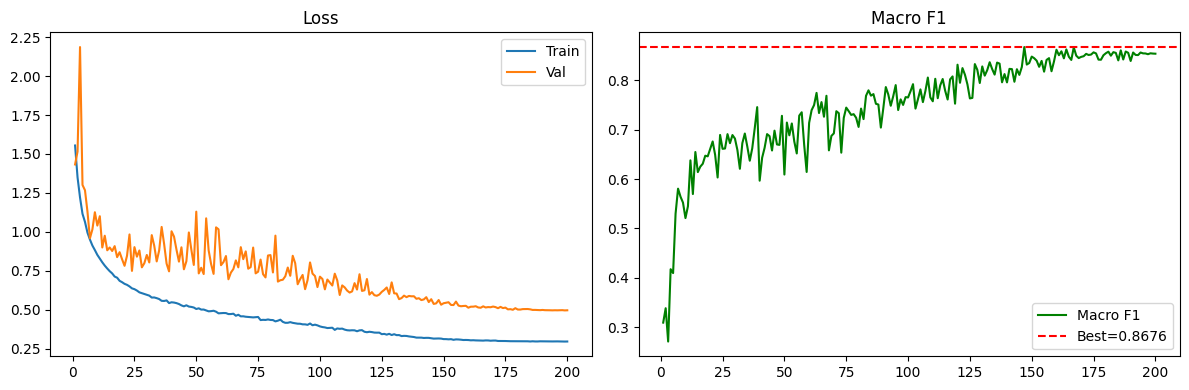

In [20]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist['epoch'], hist['tr_loss'], label='Train')
axes[0].plot(hist['epoch'], hist['vl_loss'], label='Val')
axes[0].set_title('Loss'); axes[0].legend()

axes[1].plot(hist['epoch'], hist['vl_f1'], color='green', label='Macro F1')
axes[1].axhline(best_f1, color='red', ls='--', label=f'Best={best_f1:.4f}')
axes[1].set_title('Macro F1'); axes[1].legend()

plt.tight_layout(); plt.show()

**PREDICTION**

In [21]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

sample_sub  = pd.read_csv(SAMPLE_SUB)
SUB_ID_COL  = sample_sub.columns[0]
SUB_LBL_COL = sample_sub.columns[1]
test_df     = sample_sub[[SUB_ID_COL]].copy()

TTA_ROUNDS = 5
avg_probs  = None

for t in range(TTA_ROUNDS):
    test_ds     = ImageDataset(test_df, TEST_IMG_DIR, tta_transform, SUB_ID_COL)
    test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    probs = []
    with torch.no_grad():
        for images, _ in test_loader:
            logits = model(images.to(DEVICE))
            probs.append(torch.softmax(logits, dim=1).cpu().numpy())

    probs      = np.concatenate(probs, axis=0)
    avg_probs  = probs if avg_probs is None else avg_probs + probs
    print(f'TTA round {t+1}/{TTA_ROUNDS} done')

avg_probs /= TTA_ROUNDS
all_preds  = avg_probs.argmax(axis=1)

submission = sample_sub.copy()
if submission[SUB_LBL_COL].dtype == object:
    submission[SUB_LBL_COL] = [class_names[p] for p in all_preds]
else:
    submission[SUB_LBL_COL] = all_preds

submission.to_csv('submission.csv', index=False)
print('Done! submission.csv saved.')
print(submission.head(10))


TTA round 1/5 done
TTA round 2/5 done
TTA round 3/5 done
TTA round 4/5 done
TTA round 5/5 done
Done! submission.csv saved.
   id       label
0   1    airplane
1   2  automobile
2   3         dog
3   4        frog
4   5         dog
5   6        bird
6   7        frog
7   8        bird
8   9         dog
9  10        bird


**PRE CLASS F1 REPORT**

In [26]:
model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
model.eval()

preds_v, labels_v = [], []
with torch.no_grad():
    for images, labels in val_loader:
        preds_v.extend(model(images.to(DEVICE)).argmax(1).cpu().numpy())
        labels_v.extend(labels.numpy())

print(classification_report(labels_v, preds_v, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.93      0.97      0.95       500
  automobile       0.99      1.00      0.99       500
        bird       0.93      0.88      0.91       500
         cat       0.83      0.91      0.87       500
        deer       0.95      0.87      0.90       400
         dog       0.86      0.86      0.86       400
        frog       0.89      0.78      0.83        50
       horse       0.85      0.80      0.82        50
        ship       0.96      0.87      0.91        30
       truck       0.83      0.50      0.62        10

    accuracy                           0.91      2940
   macro avg       0.90      0.84      0.87      2940
weighted avg       0.91      0.91      0.91      2940



In [27]:
# Check what the CSV looks like
print(df.head(10))
print()

# Check what the actual image files look like
import os
files = os.listdir(TRAIN_IMG_DIR)
print("Sample filenames:", files[:10])

   id       label  label_idx
0   1         cat          3
1   2         dog          5
2   3        deer          4
3   4  automobile          1
4   5        bird          2
5   6    airplane          0
6   7        deer          4
7   8    airplane          0
8   9         cat          3
9  10        bird          2

Sample filenames: ['024458.png', '026593.png', '020735.png', '016018.png', '024532.png', '014427.png', '014090.png', '028535.png', '005084.png', '014853.png']
